# Problem 2: Max-Cut with QAOA

This notebook hosts the assignment workflow for Problem 2. The implementation helpers live in `problem2/src/solver.py`.

Goal: maximize the number of crossing edges in the partition.

## Setup

Set your student-ID seed here, then run the cells below to generate the graph, compute the exact maximum cut, and compare QAOA with simulated annealing.

In [10]:
from pathlib import Path
import sys
import importlib

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

NOTEBOOK_DIR = Path.cwd()
for path in (NOTEBOOK_DIR, NOTEBOOK_DIR.parent):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import problem2.src.solver as solver
importlib.reload(solver)

approximation_ratio = solver.approximation_ratio
brute_force_max_cut = solver.brute_force_max_cut
evaluate_qaoa_landscape = solver.evaluate_qaoa_landscape
generate_student_graph = solver.generate_student_graph
graph_edges = solver.graph_edges
optimize_qaoa = solver.optimize_qaoa
sample_simulated_annealing = solver.sample_simulated_annealing

print(f"Current working directory: {Path.cwd()}")

Current working directory: /Users/linweichen/Documents/Homework/Quantum_algorithm/Hw2/problem2


In [11]:
import time

seed = 11202038  # replace with your student ID for final submission
G = generate_student_graph(seed)
exact = brute_force_max_cut(G)

print(f"Seed: {seed}")
print(f"Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}")
print(f"Edges: {graph_edges(G)}")
print(f"Exact maximum cut value: {exact.cut_value}")
print(f"Number of optimal bitstrings: {len(exact.bitstrings)}")
print("Optimal partitions:")
for left, right in zip(
    exact.partitions,
    [tuple(i for i in range(G.number_of_nodes()) if i not in p) for p in exact.partitions],
):
    print(f"  {left} | {right}")

Seed: 11202038
Nodes: 8, Edges: 19
Edges: [(0, 2), (0, 3), (0, 5), (0, 6), (0, 7), (1, 4), (1, 5), (1, 7), (2, 3), (2, 4), (2, 5), (2, 6), (2, 7), (3, 4), (3, 5), (3, 7), (4, 5), (5, 6), (6, 7)]
Exact maximum cut value: 14
Number of optimal bitstrings: 2
Optimal partitions:
  (0, 4, 5, 7) | (1, 2, 3, 6)
  (1, 2, 3, 6) | (0, 4, 5, 7)


## 2. Graph visualization

Plot the generated graph so you can inspect the exact student instance.

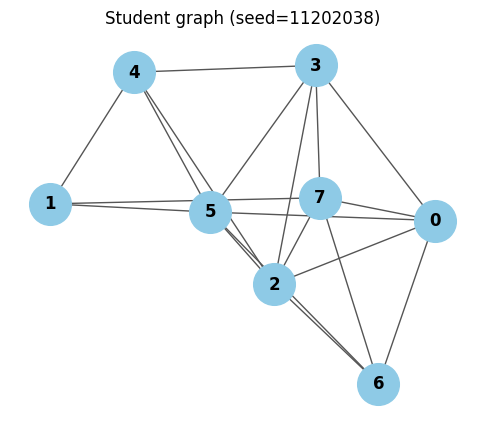

In [12]:
plt.figure(figsize=(6, 5))
pos = nx.spring_layout(G, seed=seed)
nx.draw_networkx(
    G,
    pos=pos,
    with_labels=True,
    node_color="#8ecae6",
    edge_color="#555555",
    node_size=900,
    font_weight="bold",
)
plt.title(f"Student graph (seed={seed})")
plt.axis("off")
plt.show()

## 3. p=1 QAOA energy landscape

Evaluate the 2D landscape on a grid and mark the minimum point.

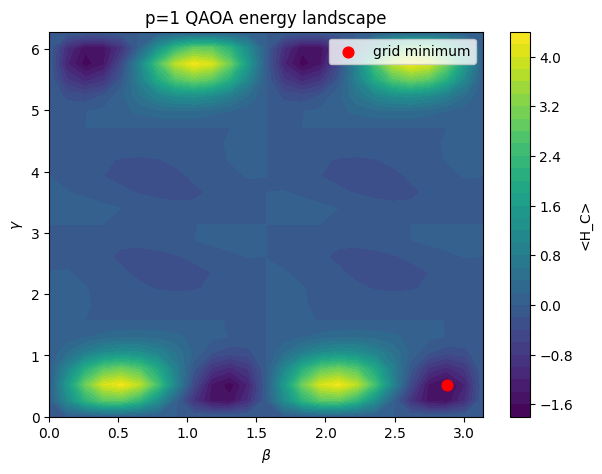

Landscape grid evaluated in 3.35s
Landscape minimum (grid): energy=-1.713336, gamma=0.523599, beta=2.879793


In [13]:
landscape_start = time.perf_counter()
gammas, betas, landscape = evaluate_qaoa_landscape(G, gamma_points=25, beta_points=25)
landscape_time = time.perf_counter() - landscape_start
min_index = np.unravel_index(np.argmin(landscape), landscape.shape)
best_gamma = gammas[min_index[0]]
best_beta = betas[min_index[1]]
best_landscape_energy = landscape[min_index]

plt.figure(figsize=(7, 5))
plt.contourf(betas, gammas, landscape, levels=30, cmap="viridis")
plt.colorbar(label="<H_C>")
plt.scatter([best_beta], [best_gamma], color="red", s=60, label="grid minimum")
plt.xlabel(r"$\beta$")
plt.ylabel(r"$\gamma$")
plt.title("p=1 QAOA energy landscape")
plt.legend()
plt.show()

print(f"Landscape grid evaluated in {landscape_time:.2f}s")
print(f"Landscape minimum (grid): energy={best_landscape_energy:.6f}, gamma={best_gamma:.6f}, beta={best_beta:.6f}")

## 4. QAOA for p = 1..4

Optimize the variational parameters at depths 1 through 4 and record the best cut and parameters.

In [14]:
qaoa_results = []
for p in range(1, 5):
    start = time.perf_counter()
    result = optimize_qaoa(G, p=p, seed=seed, steps=60, learning_rate=0.12)
    elapsed = time.perf_counter() - start
    ratio = approximation_ratio(result["cut"], exact.cut_value)
    qaoa_results.append(
        {
            "method": f"QAOA p={p}",
            "cut": result["cut"],
            "ratio": ratio,
            "time": elapsed,
            "gammas": result["gammas"],
            "betas": result["betas"],
            "bitstring": result["bitstring"],
        }
    )

for row in qaoa_results:
    print(row["method"], "cut=", row["cut"], "ratio=", f"{row['ratio']:.3f}", "time=", f"{row['time']:.2f}s")
    print("  gammas:", np.round(row["gammas"], 6).tolist())
    print("  betas :", np.round(row["betas"], 6).tolist())
    print("  bitstring:", row["bitstring"])

QAOA p=1 cut= 10 ratio= 0.714 time= 1.10s
  gammas: [3.927435]
  betas : [2.268794]
  bitstring: (0, 0, 1, 0, 1, 1, 1, 0)
QAOA p=2 cut= 10 ratio= 0.714 time= 1.69s
  gammas: [3.697055, 5.728299]
  betas : [0.446674, 2.266471]
  bitstring: (0, 0, 1, 0, 1, 0, 1, 0)
QAOA p=3 cut= 11 ratio= 0.786 time= 2.32s
  gammas: [3.654672, 4.957979, 1.997977]
  betas : [0.497114, -0.404263, 1.971571]
  bitstring: (0, 0, 1, 0, 1, 1, 1, 1)
QAOA p=4 cut= 13 ratio= 0.929 time= 2.97s
  gammas: [3.826998, 5.591699, 2.777147, 2.298054]
  betas : [0.120054, 1.838376, 1.868618, -0.0017]
  bitstring: (0, 0, 0, 0, 1, 1, 1, 1)


## 5. Simulated annealing and comparison

Run the annealer and print a compact comparison table across all methods.

In [15]:
sa_start = time.perf_counter()
sa_result = sample_simulated_annealing(G, seed=seed, num_reads=1000)
sa_elapsed = time.perf_counter() - sa_start
sa_ratio = approximation_ratio(sa_result["cut"], exact.cut_value)

comparison_rows = [
    {
        "method": "Brute force",
        "cut": exact.cut_value,
        "ratio": 1.0,
        "time": 0.0,
    },
    {
        "method": "Simulated annealing",
        "cut": sa_result["cut"],
        "ratio": sa_ratio,
        "time": sa_result["time"],
    },
]
comparison_rows.extend(
    {
        "method": row["method"],
        "cut": row["cut"],
        "ratio": row["ratio"],
        "time": row["time"],
    }
    for row in qaoa_results
)

print("Comparison summary:")
for row in comparison_rows:
    print(f"{row['method']:<18} cut={row['cut']:>2} ratio={row['ratio']:.3f} time={row['time']:.3f}s")

print("\nSimulated annealing:")
print(sa_result)
print(f"SA wrapper time: {sa_elapsed:.2f}s")

Comparison summary:
Brute force        cut=14 ratio=1.000 time=0.000s
Simulated annealing cut=14 ratio=1.000 time=0.092s
QAOA p=1           cut=10 ratio=0.714 time=1.097s
QAOA p=2           cut=10 ratio=0.714 time=1.689s
QAOA p=3           cut=11 ratio=0.786 time=2.323s
QAOA p=4           cut=13 ratio=0.929 time=2.970s

Simulated annealing:
{'bitstring': (0, 1, 1, 1, 0, 0, 1, 0), 'cut': 14, 'objective': -14.0, 'time': 0.0918062909913715, 'num_reads': 1000}
SA wrapper time: 0.09s
